In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import os

In [2]:
testnum = "Test-2 (Increased Epochs)"
model_dir = f"{testnum}/models"
plot_dir = f"{testnum}/plots"

In [3]:

# Create directory to save results
os.makedirs(testnum, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

In [4]:
# Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize and reshape the data
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode the labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


In [5]:
from tensorflow.keras import regularizers, callbacks

# Define callbacks
early_stop = callbacks.EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Build improved model
model = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


c:\Users\harsh\.conda\envs\Projects\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [7]:

# Train model
history = model.fit(
    x_train, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 161s 186ms/step - accuracy: 0.7887 - loss: 1.3305 - val_accuracy: 0.8888 - val_loss: 0.7502 - learning_rate: 0.0010
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 157s 186ms/step - accuracy: 0.8881 - loss: 0.7012 - val_accuracy: 0.9015 - val_loss: 0.6118 - learning_rate: 0.0010
Epoch 3/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 162s 192ms/step - accuracy: 0.9003 - loss: 0.5944 - val_accuracy: 0.9017 - val_loss: 0.5834 - learning_rate: 0.0010
Epoch 4/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 157s 186ms/step - accuracy: 0.9015 - loss: 0.5810 - val_accuracy: 0.9042 - val_loss: 0.5830 - learning_rate: 0.0010
Epoch 5/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 157s 185ms/step - accuracy: 0.9004 - loss: 0.6030 - val_accuracy: 0.8687 - val_loss: 0.7042 - learning_rate: 0.0010
Epoch 6/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 156s 185ms/step - accuracy: 0.9094 - loss: 0.5816 - val_accuracy: 0.9057 - val_loss: 0.6097 - learning_rate: 0.0010
Epoch 7/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 159s 188ms/step - accura

313/313 - 7s - 22ms/step - accuracy: 0.9430 - loss: 0.2982



🔥 Improved Test Accuracy: 94.30%


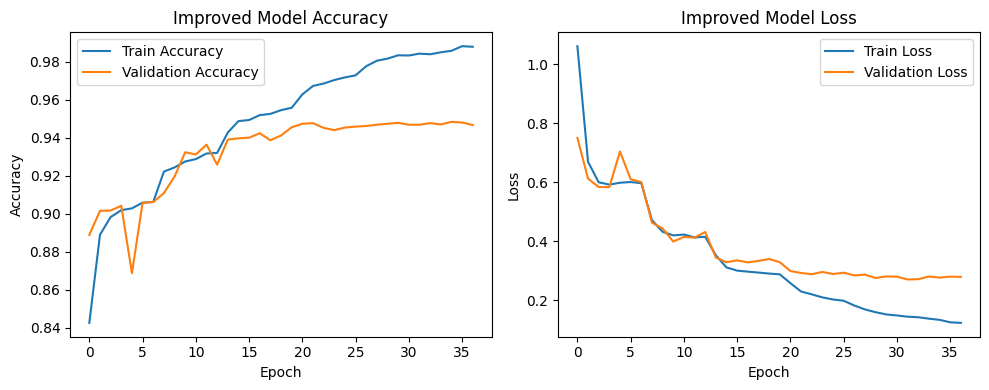

In [8]:
# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\n🔥 Improved Test Accuracy: {test_acc * 100:.2f}%")

# Save model and plot
model.save(f"{model_dir}/improved_cnn_model.h5")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Improved Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Improved Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(f"{plot_dir}/improved_cnn_training_plot.png")
plt.show()


In [9]:
# Re-define callbacks (increase patience)
early_stop = callbacks.EarlyStopping(patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)

# Retrain
history = model.fit(
    x_train, y_train_cat,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 330s 391ms/step - accuracy: 0.9871 - loss: 0.1341 - val_accuracy: 0.9472 - val_loss: 0.2749 - learning_rate: 3.1250e-05
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 281s 333ms/step - accuracy: 0.9872 - loss: 0.1301 - val_accuracy: 0.9472 - val_loss: 0.2723 - learning_rate: 3.1250e-05
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 320s 331ms/step - accuracy: 0.9886 - loss: 0.1252 - val_accuracy: 0.9467 - val_loss: 0.2711 - learning_rate: 3.1250e-05
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 268s 317ms/step - accuracy: 0.9885 - loss: 0.1222 - val_accuracy: 0.9467 - val_loss: 0.2766 - learning_rate: 3.1250e-05
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 268s 317ms/step - accuracy: 0.9898 - loss: 0.1167 - val_accuracy: 0.9467 - val_loss: 0.2718 - learning_rate: 3.1250e-05
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 274s 324ms/step - accuracy: 0.9898 - loss: 0.1150 - val_accuracy: 0.9468 - val_loss: 0.2746 - learning_rate: 3.1250e-05
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 

313/313 - 6s - 19ms/step - accuracy: 0.9439 - loss: 0.2972



🔥 Improved Test Accuracy: 94.39%


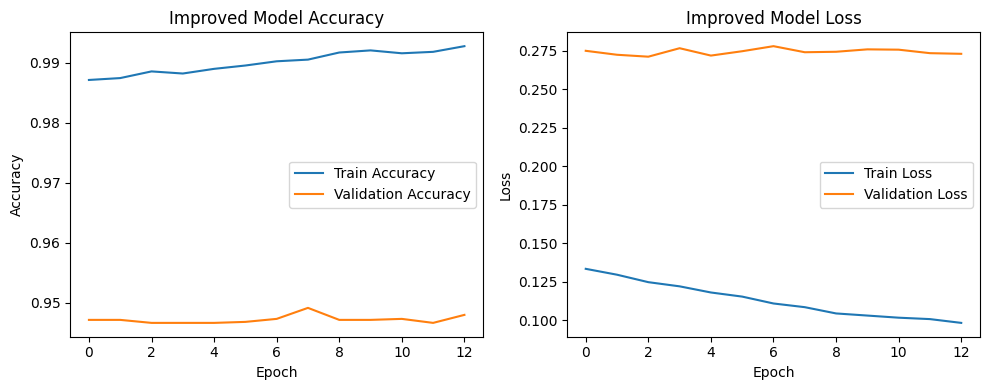

In [10]:
# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\n🔥 Improved Test Accuracy: {test_acc * 100:.2f}%")

# Save model and plot
model.save(f"{model_dir}/improved_cnn_model_retrained.h5")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Improved Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Improved Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(f"{plot_dir}/improved_cnn_training_plot_retrained.png")
plt.show()
